# Notebook 2 — LoRA Fine-tuning
## Bangla-Hindi-English Code-Switched Sentiment Analysis

| File | Used for |
|------|----------|
| `train_cleaned.csv` | Training (30k synthetic samples) |
| `val_cleaned.csv` | Validation during training (10k) |
| `test_cleaned.csv` | Primary evaluation (10k) |
| `sentmix_cleaned.csv` | Secondary evaluation (1,007 tweets) |

| | |
|---|---|
| Base model | `xlm-roberta-base` (278M params, **frozen**) |
| PEFT method | LoRA — trains < 1.5% of total parameters |

## Install Dependencies

In [1]:
!pip install transformers peft datasets scikit-learn torch seaborn matplotlib -q

## Imports & Config

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CONFIG = {
    # Model
    "model_name":     "xlm-roberta-base",
    "max_length":     192,
    # Training
    "batch_size":     32,
    "num_epochs":     5,
    "learning_rate":  1e-4,
    "weight_decay":   0.01,
    "warmup_ratio":   0.05,
    # LoRA
    "lora_r":         8,
    "lora_alpha":     16,
    "lora_dropout":   0.1,
    "target_modules": ["query", "key", "value", "dense"],
    # Data paths (output of Notebook 1)
    "train_path":        "train_cleaned.csv",
    "val_path":          "val_cleaned.csv",
    "test_path":         "test_cleaned.csv",
    "test_tweets_path": "sentmix_cleaned.csv",
}

LABEL2ID = {"Positive": 0, "Negative": 1, "Neutral": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Device: CUDA


## Load Pre-processed Datasets

In [4]:
train_df  = pd.read_csv(CONFIG["train_path"])
val_df    = pd.read_csv(CONFIG["val_path"])
test_df   = pd.read_csv(CONFIG["test_path"])
test_nat  = pd.read_csv(CONFIG["test_tweets_path"])

print(f"  Train          : {len(train_df):,}  {dict(train_df['label'].value_counts().sort_index())}")
print(f"  Val            : {len(val_df):,}   {dict(val_df['label'].value_counts().sort_index())}")
print(f"  Test (synth)   : {len(test_df):,}  {dict(test_df['label'].value_counts().sort_index())}")
print(f"  Test (SentMix) : {len(test_nat):,}  {dict(test_nat['label'].value_counts().sort_index())}")
print()
train_df.head(3)

  Train          : 29,994  {'Negative': np.int64(9999), 'Neutral': np.int64(9999), 'Positive': np.int64(9996)}
  Val            : 9,998   {'Negative': np.int64(3332), 'Neutral': np.int64(3333), 'Positive': np.int64(3333)}
  Test (synth)   : 10,000  {'Negative': np.int64(3333), 'Neutral': np.int64(3333), 'Positive': np.int64(3334)}
  Test (SentMix) : 1,007  {'Negative': np.int64(353), 'Neutral': np.int64(234), 'Positive': np.int64(420)}



,clean_text,label,label_id
0,The description reads যে প্রোগ্রাম उपयोगकर्ता ...,Negative,1
1,Procite 5 একটি ব্যক্তিগত ডেটা বেস সংগঠিত করার ...,Neutral,2
2,मुझे यह मेरे बेटे के लिए एक छोटे जलरोधक वीडियो...,Neutral,2


## Tokenisation with XLM-RoBERTa SentencePiece

XLM-RoBERTa uses a **250,000-vocabulary SentencePiece** model trained on CommonCrawl across 100 languages.

- **Zero OOV**: every Bengali, Devanagari, or Latin token is decomposed into known sub-word pieces — never `<UNK>`
- **No language tags needed**: script boundaries are learned automatically from pretraining
- **Cross-lingual alignment**: semantically similar words across languages sit close in embedding space

In [5]:
from transformers import AutoTokenizer
from datasets import Dataset

print(f"Loading tokenizer: {CONFIG['model_name']} ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

# Demo tokenisation of a code-mixed sentence
demo = "Kya match tha yaar, তুমি আর last over handle করছো!"
tokens = tokenizer.tokenize(demo)
print(f"\nDemo  : {demo}")
print(f"Tokens: {tokens}")
print(f"Count : {len(tokens)}")

Loading tokenizer: xlm-roberta-base ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Demo  : Kya match tha yaar, তুমি আর last over handle করছো!
Tokens: ['▁Kya', '▁match', '▁tha', '▁ya', 'ar', ',', '▁তুমি', '▁আর', '▁last', '▁over', '▁handle', '▁কর', 'ছো', '!']
Count : 14


In [6]:
def tokenize_fn(batch):
    return tokenizer(
        batch["clean_text"],
        truncation = True,
        padding    = "max_length",
        max_length = CONFIG["max_length"],
    )

def to_hf_dataset(df_):
    ds = Dataset.from_dict({
        "clean_text": df_["clean_text"].tolist(),
        "labels":     df_["label_id"].tolist(),
    })
    return ds.map(tokenize_fn, batched=True, batch_size=256)

print("Tokenising splits ...")
train_ds    = to_hf_dataset(train_df)
val_ds      = to_hf_dataset(val_df)
test_ds     = to_hf_dataset(test_df)
test_nat_ds = to_hf_dataset(test_nat)

print(f"  train_ds    : {len(train_ds):,}")
print(f"  val_ds      : {len(val_ds):,}")
print(f"  test_ds     : {len(test_ds):,}")
print(f"  test_nat_ds : {len(test_nat_ds):,}")

Tokenising splits ...


Map:   0%|          | 0/29994 [00:00<?, ? examples/s]

Map:   0%|          | 0/9998 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1007 [00:00<?, ? examples/s]

  train_ds    : 29,994
  val_ds      : 9,998
  test_ds     : 10,000
  test_nat_ds : 1,007


## Build LoRA Model

### How LoRA works

For each targeted weight matrix $W$ in an attention layer:

$$W' = \underbrace{W}_{\text{frozen}} + \underbrace{\frac{\alpha}{r} \cdot B \cdot A}_{\text{trained}}$$

where $A \in \mathbb{R}^{r \times k}$, $B \in \mathbb{R}^{d \times r}$, and $r \ll \min(d,k)$.

With `r=8`, `alpha=16`, adapting `query` and `value` across all 12 XLM-RoBERTa layers:
- **~887k trainable parameters** (the A and B matrices only)
- **~278M frozen parameters** (original XLM-RoBERTa weights — never modified)
- No catastrophic forgetting of multilingual knowledge

In [7]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

print(f"Loading {CONFIG['model_name']} ...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels              = len(LABEL2ID),
    id2label                = ID2LABEL,
    label2id                = LABEL2ID,
    ignore_mismatched_sizes = True,
)

lora_config = LoraConfig(
    task_type      = TaskType.SEQ_CLS,
    r              = CONFIG["lora_r"],
    lora_alpha     = CONFIG["lora_alpha"],
    lora_dropout   = CONFIG["lora_dropout"],
    target_modules = CONFIG["target_modules"],
    bias           = "none",
)

model = get_peft_model(base_model, lora_config)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
pct              = 100 * trainable_params / total_params

print("\n" + "─"*55)
print("  LoRA Parameter Breakdown")
print("─"*55)
print(f"  Total parameters       : {total_params:>12,}")
print(f"  Trainable (LoRA only)  : {trainable_params:>12,}  ({pct:.3f}%)")
print(f"  Frozen (XLM-R base)    : {frozen_params:>12,}")
print("─"*55)
print(f"  LoRA rank (r)          : {CONFIG['lora_r']}")
print(f"  LoRA alpha             : {CONFIG['lora_alpha']}")
print(f"  Effective scale (α/r)  : {CONFIG['lora_alpha']/CONFIG['lora_r']:.1f}×")
print(f"  Target modules         : {CONFIG['target_modules']}")
print("─"*55)

Loading xlm-roberta-base ...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



───────────────────────────────────────────────────────
  LoRA Parameter Breakdown
───────────────────────────────────────────────────────
  Total parameters       :  279,965,958
  Trainable (LoRA only)  :    1,920,003  (0.686%)
  Frozen (XLM-R base)    :  278,045,955
───────────────────────────────────────────────────────
  LoRA rank (r)          : 8
  LoRA alpha             : 16
  Effective scale (α/r)  : 2.0×
  Target modules         : ['query', 'key', 'value', 'dense']
───────────────────────────────────────────────────────


## Training Setup

In [8]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "weighted_f1": round(f1_score(labels, preds, average="weighted"), 4),
        "macro_f1":    round(f1_score(labels, preds, average="macro"),    4),
        "accuracy":    round(accuracy_score(labels, preds),               4),
    }

training_args = TrainingArguments(
    output_dir                  = "./lora_checkpoints",
    num_train_epochs            = CONFIG["num_epochs"],
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = CONFIG["learning_rate"],
    weight_decay                = CONFIG["weight_decay"],
    warmup_ratio                = CONFIG["warmup_ratio"],  # fixed: was warmup_steps=0.06 (wrong type)
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "weighted_f1",
    greater_is_better           = True,
    logging_steps               = 100,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = "none",
    label_names                 = ["labels"],
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)

steps_per_epoch = len(train_ds) // CONFIG["batch_size"]
total_steps     = steps_per_epoch * CONFIG["num_epochs"]
warmup_steps    = int(total_steps * CONFIG["warmup_ratio"])
print(f"Steps per epoch : {steps_per_epoch:,}")
print(f"Total steps     : {total_steps:,}")
print(f"Warmup steps    : {warmup_steps:,}  ({CONFIG['warmup_ratio']*100:.0f}% of total)")
print(f"Trainable params: {trainable_params:,} ({pct:.3f}% of total)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Steps per epoch : 937
Total steps     : 4,685
Warmup steps    : 234  (5% of total)
Trainable params: 1,920,003 (0.686% of total)


## Training

In [9]:
import warnings
warnings.filterwarnings("ignore")

print(f"  Training on {len(train_ds):,} samples for {CONFIG['num_epochs']} epochs")
print(f"  Batch size : {CONFIG['batch_size']}  |  Steps per epoch : {len(train_ds)//CONFIG['batch_size']:,}\n")

t0 = time.time()
trainer.train()
elapsed = time.time() - t0

print(f"\n Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

  Training on 29,994 samples for 5 epochs
  Batch size : 32  |  Steps per epoch : 937



Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1,Accuracy
1,0.687539,0.643764,0.719900,0.719900,0.721800
2,0.645036,0.631195,0.736400,0.736400,0.734100
3,0.597678,0.614796,0.739100,0.739100,0.738800
4,0.611797,0.625469,0.740000,0.740000,0.740900
5,0.570658,0.620238,0.743000,0.743100,0.742500



 Training complete in 1845.6s (30.8 min)


## Evaluation

Evaluating on test set



── Test Set ────────────────────────
              precision    recall  f1-score   support

    Positive     0.8262    0.8182    0.8222      3334
    Negative     0.7672    0.7546    0.7609      3333
     Neutral     0.6459    0.6628    0.6542      3333

    accuracy                         0.7452     10000
   macro avg     0.7464    0.7452    0.7458     10000
weighted avg     0.7464    0.7452    0.7458     10000



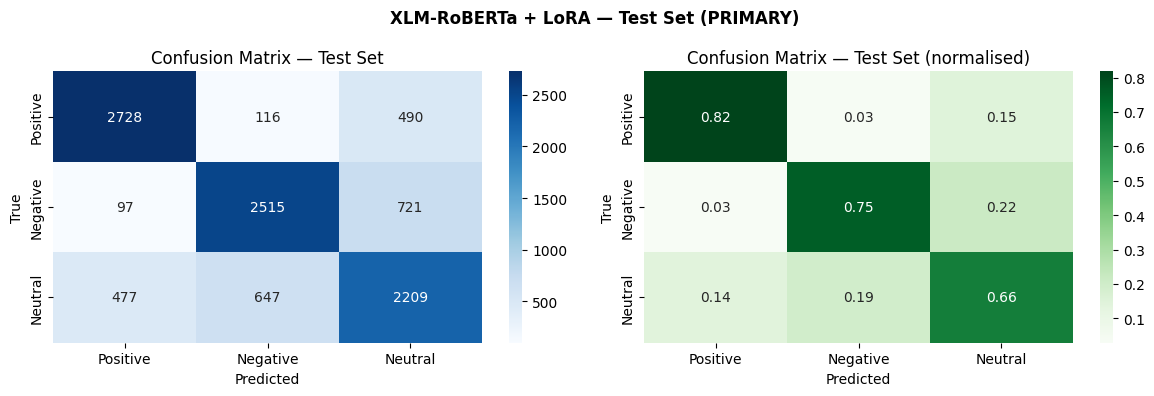

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating on test set")
preds  = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = preds.label_ids

print("\n── Test Set ────────────────────────")
print(classification_report(y_true, y_pred,
      target_names=list(LABEL2ID.keys()), digits=4))

report    = classification_report(y_true, y_pred,
                  target_names=list(LABEL2ID.keys()), digits=4, output_dict=True)
weighted_f1 = report["weighted avg"]["f1-score"]
macro_f1    = report["macro avg"]["f1-score"]
accuracy    = report["accuracy"]

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[0])
axes[0].set_title("Confusion Matrix — Test Set")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[1])
axes[1].set_title("Confusion Matrix — Test Set (normalised)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("XLM-RoBERTa + LoRA — Test Set (PRIMARY)", fontweight="bold")
plt.tight_layout()
plt.show()

## Evaluation — SentMix-3L (Secondary)

Evaluating on SentMix-3L natural test set ...



── SentMix-3L Natural Test Set ─────────────────────
              precision    recall  f1-score   support

    Positive     0.6220    0.9833    0.7620       420
    Negative     0.9066    0.4674    0.6168       353
     Neutral     0.2857    0.1966    0.2329       234

    accuracy                         0.6197      1007
   macro avg     0.6048    0.5491    0.5372      1007
weighted avg     0.6436    0.6197    0.5882      1007



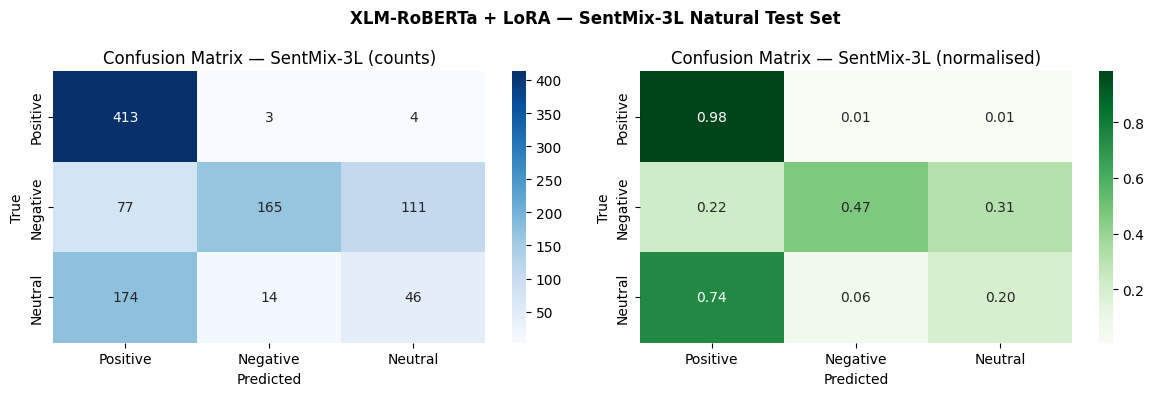

In [11]:
print("Evaluating on SentMix-3L natural test set ...")
preds_nat  = trainer.predict(test_nat_ds)
y_pred_nat = np.argmax(preds_nat.predictions, axis=-1)
y_true_nat = preds_nat.label_ids

print("\n── SentMix-3L Natural Test Set ─────────────────────")
print(classification_report(y_true_nat, y_pred_nat,
      target_names=list(LABEL2ID.keys()), digits=4))

report_nat      = classification_report(y_true_nat, y_pred_nat,
                  target_names=list(LABEL2ID.keys()), digits=4, output_dict=True)
weighted_f1_nat = report_nat["weighted avg"]["f1-score"]
macro_f1_nat    = report_nat["macro avg"]["f1-score"]
accuracy_nat    = report_nat["accuracy"]

# ── Confusion matrix ──────────────────────────────────────────────────────
cm_nat = confusion_matrix(y_true_nat, y_pred_nat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_nat, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[0])
axes[0].set_title("Confusion Matrix — SentMix-3L (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

cm_nat_norm = cm_nat.astype(float) / cm_nat.sum(axis=1, keepdims=True)
sns.heatmap(cm_nat_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=list(LABEL2ID.keys()),
            yticklabels=list(LABEL2ID.keys()), ax=axes[1])
axes[1].set_title("Confusion Matrix — SentMix-3L (normalised)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.suptitle("XLM-RoBERTa + LoRA — SentMix-3L Natural Test Set", fontweight="bold")
plt.tight_layout()
plt.show()

## Results Summary

In [12]:
print("=" * 58)
print("  FINAL RESULTS SUMMARY")
print("=" * 58)
print(f"  Model              : {CONFIG['model_name']}")
print(f"  PEFT method        : LoRA")
print()
print("  ── Parameters ───────────────────────────────────────")
print(f"  Total params       : {total_params:>12,}")
print(f"  Trainable (LoRA)   : {trainable_params:>12,}  ({pct:.3f}%)")
print(f"  Frozen (XLM-R)     : {frozen_params:>12,}")
print()
print("  ── Training ─────────────────────────────────────────")
print(f"  Epochs             : {CONFIG['num_epochs']}")
print(f"  Training time      : {elapsed:.1f}s  ({elapsed/60:.1f} min)")
print(f"  Batch size         : {CONFIG['batch_size']}")
print(f"  Learning rate      : {CONFIG['learning_rate']}")
print()
print("  ── Primary: Synthetic Test Set ──────────────────────")
print(f"  Weighted F1        : {weighted_f1:.4f}")
print(f"  Macro F1           : {macro_f1:.4f}")
print(f"  Accuracy           : {accuracy:.4f}  ({accuracy*100:.1f}%)")
print()
print("  ── Secondary: SentMix-3L Natural Test Set ───────────")
print(f"  Weighted F1        : {weighted_f1_nat:.4f}")
print(f"  Macro F1           : {macro_f1_nat:.4f}")
print(f"  Accuracy           : {accuracy_nat:.4f}  ({accuracy_nat*100:.1f}%)")
print("=" * 58)

summary = {
    "model": CONFIG["model_name"],
    "lora": {"r": CONFIG["lora_r"], "alpha": CONFIG["lora_alpha"],
             "dropout": CONFIG["lora_dropout"], "target_modules": CONFIG["target_modules"]},
    "params": {"total": total_params, "trainable": trainable_params,
               "frozen": frozen_params, "trainable_pct": round(pct, 4)},
    "training": {"epochs": CONFIG["num_epochs"], "time_sec": round(elapsed, 2),
                 "lr": CONFIG["learning_rate"], "batch_size": CONFIG["batch_size"]},
    "primary_test_synthetic": {
        "weighted_f1": round(weighted_f1, 4),
        "macro_f1":    round(macro_f1, 4),
        "accuracy":    round(accuracy, 4),
    },
    "secondary_test_sentmix3l": {
        "weighted_f1": round(weighted_f1_nat, 4),
        "macro_f1":    round(macro_f1_nat, 4),
        "accuracy":    round(accuracy_nat, 4),
    },
    "confusion_matrix_synthetic": cm.tolist(),
    "confusion_matrix_sentmix3l": cm_nat.tolist(),
}
with open("lora_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved → lora_results_summary.json ✓")

  FINAL RESULTS SUMMARY
  Model              : xlm-roberta-base
  PEFT method        : LoRA

  ── Parameters ───────────────────────────────────────
  Total params       :  279,965,958
  Trainable (LoRA)   :    1,920,003  (0.686%)
  Frozen (XLM-R)     :  278,045,955

  ── Training ─────────────────────────────────────────
  Epochs             : 5
  Training time      : 1845.6s  (30.8 min)
  Batch size         : 32
  Learning rate      : 0.0001

  ── Primary: Synthetic Test Set ──────────────────────
  Weighted F1        : 0.7458
  Macro F1           : 0.7458
  Accuracy           : 0.7452  (74.5%)

  ── Secondary: SentMix-3L Natural Test Set ───────────
  Weighted F1        : 0.5882
  Macro F1           : 0.5372
  Accuracy           : 0.6197  (62.0%)

Saved → lora_results_summary.json ✓


## Inference Demo

In [ ]:
DEMO_SENTENCES = [
    ("আজকের দিনটা khub bhalo ছিল, I am so happy today!",         "Positive"),
    ("Aaj main bahut khush hoon কারণ আমার result ভালো হয়েছে!",  "Positive"),
    ("यह फिल्म একদম bakwas ছিল, worst movie I have ever seen.",   "Negative"),
    ("দিনটা বাজে গেছে, sab kuch galat ho gaya today.",             "Negative"),
    ("আবহাওয়া আজ theek hai, kuch khaas nahi.",                    "Neutral"),
    ("Main office গেছি, কাজ শেষ করলাম, ghar wapis aa gaya.",     "Neutral"),
]

import re, unicodedata

def quick_clean(text):
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"https?://\S+|@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

device = next(model.parameters()).device

model.eval()
print("─"*70)
print(f"{'Input (truncated)':<44} {'True':>10} {'Pred':>10} {'Conf':>7}")
print("─"*70)

for text, true_label in DEMO_SENTENCES:
    clean = quick_clean(text)
    enc   = tokenizer(clean, return_tensors="pt", truncation=True,
                      max_length=CONFIG["max_length"], padding=True)
    enc   = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
      out   = model(**enc)
    probs   = torch.softmax(out.logits, -1)
    pred_id = probs.argmax(-1).item()
    conf    = probs.max().item()
    match   = "✓" if ID2LABEL[pred_id] == true_label else "✗"
    print(f"{match} {text[:42]:<42} {true_label:>10} {ID2LABEL[pred_id]:>10} {conf:>6.1%}")

print("─"*70)

──────────────────────────────────────────────────────────────────────
Input (truncated)                                  True       Pred    Conf
──────────────────────────────────────────────────────────────────────
✓ আজকের দিনটা khub bhalo ছিল, I am so happy    Positive   Positive  40.7%
✓ Aaj main bahut khush hoon কারণ আমার result   Positive   Positive  93.4%
✓ यह फिल्म একদম bakwas ছিল, worst movie I ha   Negative   Negative  99.1%
✗ দিনটা বাজে গেছে, sab kuch galat ho gaya to   Negative    Neutral  71.1%
✓ আবহাওয়া আজ theek hai, kuch khaas nahi.       Neutral    Neutral  79.8%
✗ Main office গেছি, কাজ শেষ করলাম, ghar wapi    Neutral   Positive  34.0%
──────────────────────────────────────────────────────────────────────


## Save LoRA Adapter

In [14]:
from peft import PeftModel

ADAPTER_PATH = "/content/model/"
model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

adapter_size_mb = sum(
    os.path.getsize(os.path.join(ADAPTER_PATH, f))
    for f in os.listdir(ADAPTER_PATH)
) / 1e6
print(f"Adapter saved : {ADAPTER_PATH}")
print(f"Adapter size  : {adapter_size_mb:.1f} MB")

Adapter saved : /content/model/
Adapter size  : 24.5 MB
